In [1]:
import pandas as pd
import numpy as np

# Define file paths
cohort_path = '/Users/khoale/Downloads/Alzheimer_Code/adni_pet_mri_cohort_2.csv'
ucsf_path = '/Users/khoale/Downloads/TABLE_DATA_ADNI/UCSFFSX7_08Jul2026.csv'

# Load the cohort data
cohort_df = pd.read_csv(cohort_path)

# Ensure the MRI date column is a proper datetime object for comparison
cohort_df['MRI_AcqDate'] = pd.to_datetime(cohort_df['MRI_AcqDate'])

# Display all patients in the cohort with their Subject ID and Date
print(f"Total patients in cohort: {len(cohort_df)}\n")
display(cohort_df[['PTID', 'MRI_AcqDate']])

Total patients in cohort: 600



,PTID,MRI_AcqDate
0,003_S_1057,2006-12-04
1,003_S_1059,2006-11-09
2,003_S_1257,2007-03-01
3,003_S_4119,2011-08-09
4,003_S_4136,2011-08-10
...,...,...
595,941_S_4255,2011-10-07
596,941_S_4292,2011-12-05
597,941_S_4376,2012-01-06
598,941_S_4764,2012-06-01


In [2]:
# Load the UCSF FreeSurfer data
# low_memory=False is used because the UCSF file has many columns with mixed data types
ucsf_df = pd.read_csv(ucsf_path, low_memory=False)

# Convert UCSF EXAMDATE to datetime (coerce handles any weirdly formatted dates)
ucsf_df['EXAMDATE'] = pd.to_datetime(ucsf_df['EXAMDATE'], errors='coerce')

print("--- MATCHING COHORT TO UCSF SCANS ---\n")

# Initialize a counter for our matches
total_matches = 0

# Loop through our cohort and find all matching dates in UCSF
for index, row in cohort_df.iterrows():
    patient_id = row['PTID']
    cohort_date = row['MRI_AcqDate']
    
    # Find all UCSF scans for this specific patient
    patient_ucsf_scans = ucsf_df[ucsf_df['PTID'] == patient_id]
    
    # Print the Cohort information
    date_str = cohort_date.strftime('%Y-%m-%d') if pd.notnull(cohort_date) else 'NaT'
    print(f"Cohort Patient: {patient_id} | Cohort MRI Date: {date_str}")
    
    # Print the UCSF information
    if patient_ucsf_scans.empty:
        print("  -> No scans found for this patient in UCSF dataset.")
    else:
        print("  -> UCSF Exam Dates found for this patient:")
        
        # Loop through every UCSF scan this patient has and print the date
        for _, ucsf_row in patient_ucsf_scans.iterrows():
            ucsf_date = ucsf_row['EXAMDATE']
            
            # Calculate the gap in days
            if pd.notnull(ucsf_date) and pd.notnull(cohort_date):
                gap_days = abs((ucsf_date - cohort_date).days)
                
                # Check if it's an exact or very close match (within 30 days)
                if gap_days == 0:
                    match_label = " <-- [MATCH]"
                    total_matches += 1
                else:
                    match_label = ""
                    
                print(f"     - {ucsf_date.strftime('%Y-%m-%d')} (Gap: {gap_days} days){match_label}")
            else:
                print(f"     - {ucsf_date} (Invalid Date)")
                
    print("-" * 50)

# Print the final count of matches at the end
print("\n" + "=" * 50)
print(f"FINAL RESULT: Found {total_matches} successful matches (within 30 days) for {len(cohort_df)} cohort patients.")
print("=" * 50)

--- MATCHING COHORT TO UCSF SCANS ---

Cohort Patient: 003_S_1057 | Cohort MRI Date: 2006-12-04
  -> UCSF Exam Dates found for this patient:
     - 2007-10-23 (Gap: 323 days)
     - 2010-01-28 (Gap: 1151 days)
     - 2008-02-08 (Gap: 431 days)
     - 2009-03-21 (Gap: 838 days)
     - 2006-12-04 (Gap: 0 days) <-- [MATCH]
--------------------------------------------------
Cohort Patient: 003_S_1059 | Cohort MRI Date: 2006-11-09
  -> UCSF Exam Dates found for this patient:
     - 2008-12-23 (Gap: 775 days)
     - 2006-11-09 (Gap: 0 days) <-- [MATCH]
     - 2007-06-18 (Gap: 221 days)
--------------------------------------------------
Cohort Patient: 003_S_1257 | Cohort MRI Date: 2007-03-01
  -> UCSF Exam Dates found for this patient:
     - 2007-03-01 (Gap: 0 days) <-- [MATCH]
     - 2008-05-15 (Gap: 441 days)
--------------------------------------------------
Cohort Patient: 003_S_4119 | Cohort MRI Date: 2011-08-09
  -> UCSF Exam Dates found for this patient:
     - 2012-08-28 (Gap: 385 d

In [3]:
import pandas as pd
import numpy as np

# 1. Load Data
cohort_path = '/Users/khoale/Downloads/Alzheimer_Code/adni_pet_mri_cohort_2.csv'
ucsf_path = '/Users/khoale/Downloads/TABLE_DATA_ADNI/UCSFFSX7_08Jul2026.csv'

cohort_df = pd.read_csv(cohort_path)
ucsf_df = pd.read_csv(ucsf_path, low_memory=False)

# 2. Drop all PET-related columns from the cohort
pet_cols_to_drop = [
    'PET_ImageID', 'PET_Description', 'PET_AcqDate', 'PET_Tier', 
    'Gap_MRI_PET', 'Gap_PET_DX'
]
cohort_df = cohort_df.drop(columns=pet_cols_to_drop, errors='ignore')

# 3. Ensure datetime types for accurate matching
cohort_df['MRI_AcqDate'] = pd.to_datetime(cohort_df['MRI_AcqDate'])
ucsf_df['EXAMDATE'] = pd.to_datetime(ucsf_df['EXAMDATE'], errors='coerce')

# Rename UCSF's EXAMDATE to 'UCSF_EXAMDATE' 
# (This prevents it from overriding your cohort's 'EXAMDATE' column which stores the Diagnosis Date)
ucsf_df = ucsf_df.rename(columns={'EXAMDATE': 'UCSF_EXAMDATE'})

# 4. Perform nearest-date merge using 'merge_asof'
# Note: 'merge_asof' requires both dataframes to be sorted by the date column first
cohort_df = cohort_df.sort_values('MRI_AcqDate').dropna(subset=['MRI_AcqDate'])
ucsf_df = ucsf_df.sort_values('UCSF_EXAMDATE').dropna(subset=['UCSF_EXAMDATE'])

merged_df = pd.merge_asof(
    cohort_df,
    ucsf_df,
    left_on='MRI_AcqDate',     # Date from the cohort
    right_on='UCSF_EXAMDATE',  # Date from UCSF
    by='PTID',                 # Must be the exact same patient
    direction='nearest',       # Find the closest date
    tolerance=pd.Timedelta(days=1) # Must be within 1 day
)

# 5. Drop the un-matched rows (the ~23 patients who didn't have a UCSF scan within 30 days)
# If a match wasn't found within 30 days, pandas fills UCSF_EXAMDATE with NaT
final_df = merged_df.dropna(subset=['UCSF_EXAMDATE']).copy()

# Sort back by PTID to make the final table neat and clean
final_df = final_df.sort_values('PTID').reset_index(drop=True)

# 6. Print summary and save
print(f"Original cohort size: {len(cohort_df)}")
print(f"Successfully merged size: {len(final_df)}")

output_path = 'adni_mri_ucsf_merged.csv'
final_df.to_csv(output_path, index=False)
print(f"\nSuccessfully saved merged data to: {output_path}")

# Display a preview of the new combined dataframe
display(final_df.head())

Original cohort size: 600
Successfully merged size: 577

Successfully saved merged data to: adni_mri_ucsf_merged.csv


,PTID,PTID.1,Label,EXAMDATE,MRI_ImageID,MRI_Description,MRI_AcqDate,MRI_Tier,Gap_MRI_DX,PHASE,...,ST147SV,ST148SV,ST149SV,ST150SV,ST151SV,ST152SV,ST153SV,ST154SV,ST155SV,update_stamp
0,003_S_1057,003_S_1057,pMCI,2007-02-09,I52820,MPR; GradWarp; B1 Correction; N3,2006-12-04,0,67,ADNI1,...,202578.520495,196599.520347,399178.040842,200389.0,200052.0,400441.0,48674.0,540659.040842,868045.0,2025-05-12 13:00:31
1,003_S_1059,003_S_1059,AD,2006-12-12,I52811,MPR; GradWarp; B1 Correction; N3,2006-11-09,0,33,ADNI1,...,171081.454377,174362.962815,345444.417192,199732.5,200761.5,400494.0,40631.0,467840.417192,862833.0,2025-05-12 13:00:31
2,003_S_1257,003_S_1257,AD,2007-03-28,I52789,MPR; GradWarp; B1 Correction; N3,2007-03-01,0,27,ADNI1,...,200162.025056,204979.618725,405141.643781,267964.5,269458.5,537423.0,61511.0,581524.643781,1143473.0,2025-05-12 13:00:31
3,003_S_4119,003_S_4119,CN,2011-08-18,I254756,MT1; GradWarp; N3m,2011-08-09,2,9,ADNI2,...,228094.276651,228897.542983,456991.819634,230552.5,232450.5,463003.0,51366.0,619738.819634,1017644.0,2024-12-02 08:27:54
4,003_S_4152,003_S_4152,AD,2011-09-27,I255415,MT1; GradWarp; N3m,2011-08-30,2,28,ADNI2,...,191946.161967,206303.483563,398249.645529,207561.0,212105.0,419666.0,48997.0,542729.645529,925919.0,2024-12-02 08:27:54


--- CLASS DISTRIBUTION ---

Number of subjects in each class:
Label
CN      186
AD      159
pMCI    116
sMCI    116

Percentage of subjects in each class:
Label
CN      32.24%
AD      27.56%
pMCI     20.1%
sMCI     20.1%


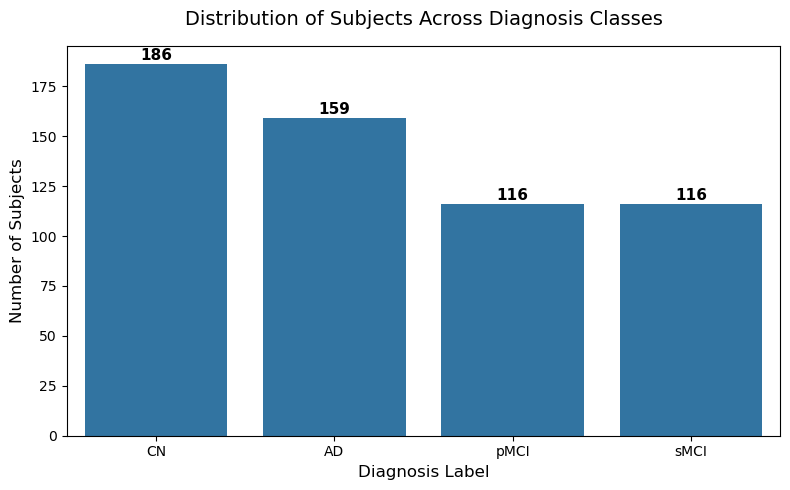

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# If you are continuing from the previous cell, 'final_df' is already in memory.
# If you are starting fresh, uncomment the line below to load the file:
# final_df = pd.read_csv('adni_mri_ucsf_merged.csv')

print("--- CLASS DISTRIBUTION ---")

# 1. Get raw counts of how many subjects are in each class
class_counts = final_df['Label'].value_counts()
print("\nNumber of subjects in each class:")
print(class_counts.to_string())

# 2. Get the percentages
class_percentages = final_df['Label'].value_counts(normalize=True) * 100
print("\nPercentage of subjects in each class:")
print((class_percentages.round(2).astype(str) + '%').to_string())

# 3. Visualize the distribution with a bar chart
plt.figure(figsize=(8, 5))
# Using seaborn to create a colored bar chart, ordered from highest count to lowest
sns.countplot(data=final_df, x='Label', order=class_counts.index)

plt.title('Distribution of Subjects Across Diagnosis Classes', fontsize=14, pad=15)
plt.xlabel('Diagnosis Label', fontsize=12)
plt.ylabel('Number of Subjects', fontsize=12)

# Add the count numbers on top of the bars
for i, count in enumerate(class_counts):
    plt.text(i, count + 2, str(count), ha='center', fontsize=11, fontweight='bold')

# Clean up the layout and display
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# Define paths
datadic_path = '/Users/khoale/Downloads/TABLE_DATA_ADNI/DATADIC_08Jul2026.csv'

# 1. Load your merged data and the master data dictionary
# (If final_df is already in memory, we just use final_df.columns)
merged_cols = final_df.columns 
datadic = pd.read_csv(datadic_path, low_memory=False)

# 2. Filter the Data Dictionary for the UCSF FreeSurfer Version 7 table
# In ADNI, the table name (TBLNAME) matches the prefix of the csv filename
ucsf_dict = datadic[datadic['TBLNAME'] == 'UCSFFSX7'].copy()

# Fallback just in case the table name is formatted slightly differently
if ucsf_dict.empty:
    ucsf_dict = datadic[datadic['TBLNAME'].str.contains('UCSF', case=False, na=False)]

# 3. Create a fast lookup dictionary (Column Name -> Description)
# We convert keys to uppercase to ensure we don't miss matches due to capitalization
description_map = dict(zip(ucsf_dict['FLDNAME'].str.upper(), ucsf_dict['TEXT']))

print("--- UCSF FREESURFER REGION DEFINITIONS ---\n")
found_count = 0

# 4. Loop through the columns in your merged dataset and print the definition if it's a UCSF column
for col in merged_cols:
    col_upper = col.upper()
    # Check if this column exists in the UCSF dictionary
    if col_upper in description_map:
        description = description_map[col_upper]
        # Format it nicely so the columns align
        print(f"{col: <15} | {description}")
        found_count += 1

print("\n" + "=" * 60)
print(f"Successfully matched and defined {found_count} UCSF columns in your dataset!")
print("=" * 60)

--- UCSF FREESURFER REGION DEFINITIONS ---

PTID            | Participant Identifier for the in-clinic ADNI study
EXAMDATE        | When the image was collected.
PHASE           | Phase of the study in which this observation was collected
RID             | Participant Identifier for the in-clinic ADNI study
VISCODE         | VISCODE of the Image
IMAGEUID        | Image UID of image that was processed.
FIELD_STRENGTH  | the field strength (tesla) of the image
RUNDATE         | When the image was processed.
STATUS          | partial = No QC, not final. Complete = QC and finalized.
FSVER           | Specific version of FreeSurfer used. All FS 7.x results are compatible.
OVERALLQC       | An overall quality rating. Refer to additional QC variables for Partial rating.
TEMPQC          | QC rating of temporal lobe. Fail affects the following regions: LeftTemporalPole (ST60); RightTemporalPole (ST119); LeftFusiform (ST26); RightFusiform (ST85); LeftSuperiorTemporal (ST58); RightSuperiorTempora

In [6]:
print("--- MISSING COLUMNS IN DATA DICTIONARY ---\n")

missing_cols = []

# Loop through all the columns from the UCSF dataframe
# (Converting to uppercase just like we did with the dictionary)
for col in ucsf_df.columns:
    col_upper = col.upper()
    
    # Check if this column is missing from our description_map
    if col_upper not in description_map:
        missing_cols.append(col)
        
# Print the results
print(f"Found {len(missing_cols)} columns in the UCSF file that are missing from the dictionary:")

for col in missing_cols:
    # If it's the one we renamed, add a helpful note
    if col == 'UCSF_EXAMDATE':
        print(f" - {col} (We manually renamed this from EXAMDATE in Cell 3)")
    else:
        print(f" - {col}")

--- MISSING COLUMNS IN DATA DICTIONARY ---

Found 3 columns in the UCSF file that are missing from the dictionary:
 - VISCODE2
 - UCSF_EXAMDATE (We manually renamed this from EXAMDATE in Cell 3)
 - update_stamp


In [7]:
# The specific QC columns you requested
qc_columns = [
    'TEMPQC', 'FRONTQC', 'PARQC', 'INSULAQC', 
    'OCCQC', 'BGQC', 'CWMQC', 'VENTQC', 'HIPPOQC'
]

print("--- QUALITY CONTROL CHECK FOR YOUR SUBJECTS ---\n")

# Loop through each QC column and count the results
for qc_col in qc_columns:
    if qc_col in final_df.columns:
        print(f"Distribution for {qc_col}:")
        
        # Get the counts of each value (including NaN/blank values if any)
        counts = final_df[qc_col].value_counts(dropna=False)
        
        # Print them out nicely
        for value, count in counts.items():
            print(f"   - {value}: {count} subjects")
        print()
    else:
        print(f"WARNING: Column {qc_col} not found in the dataset.\n")


# Optional Bonus: Let's calculate how many subjects had ZERO failures across all regions
perfect_pass_df = final_df.copy()

for qc_col in qc_columns:
    if qc_col in perfect_pass_df.columns:
        # We drop any row that has the word "Fail" or the number "4" (ADNI's numeric code for Fail)
        mask = ~perfect_pass_df[qc_col].astype(str).str.contains('Fail|4', case=False, na=False)
        perfect_pass_df = perfect_pass_df[mask]

print("-" * 50)
print(f"Total subjects with NO explicit 'Fail' in ANY of these regions: {len(perfect_pass_df)} out of {len(final_df)}")
print("-" * 50)

--- QUALITY CONTROL CHECK FOR YOUR SUBJECTS ---

Distribution for TEMPQC:
   - nan: 577 subjects

Distribution for FRONTQC:
   - nan: 577 subjects

Distribution for PARQC:
   - nan: 577 subjects

Distribution for INSULAQC:
   - nan: 577 subjects

Distribution for OCCQC:
   - nan: 577 subjects

Distribution for BGQC:
   - nan: 577 subjects

Distribution for CWMQC:
   - nan: 577 subjects

Distribution for VENTQC:
   - nan: 577 subjects

Distribution for HIPPOQC:
   - nan: 577 subjects

--------------------------------------------------
Total subjects with NO explicit 'Fail' in ANY of these regions: 577 out of 577
--------------------------------------------------


In [8]:
# Find all columns in your final dataset that start with 'ST'
# (We convert to uppercase first just in case any were saved as 'st')
st_columns = [col for col in final_df.columns if col.upper().startswith('ST')]

print(f"There are exactly {len(st_columns)} 'ST' (structural measurement) columns in the dataset!")

# Optional: Print out the first 10 just to see what they look like
print("\nHere is a sample of what those columns look like:")
print(st_columns[:10])

There are exactly 326 'ST' (structural measurement) columns in the dataset!

Here is a sample of what those columns look like:
['STATUS', 'ST101SV', 'ST102CV', 'ST102SA', 'ST102TA', 'ST102TS', 'ST103CV', 'ST103SA', 'ST103TA', 'ST103TS']


In [9]:
# 1. Identify all the structural (ST) columns in your dataset
st_columns = [col for col in final_df.columns if col.upper().startswith('ST')]

# 2. Define our biological keywords for fluid-filled spaces
# (Note: We include 'VENTRICAL' because the ADNI dictionary actually has a typo for the 5th ventricle!)
fluid_keywords = ['VENTRICLE', 'VENTRICAL', 'CSF', 'CHOROID']

fluid_cols = []

# 3. Loop through every ST column and check its official biological definition
for col in st_columns:
    col_upper = col.upper()
    
    if col_upper in description_map:
        # Get the official definition and make it uppercase for easy searching
        definition = description_map[col_upper].upper()
        
        # Check if any of our fluid keywords are in the definition
        if any(keyword in definition for keyword in fluid_keywords):
            fluid_cols.append(col)

print(f"Biologically identified {len(fluid_cols)} fluid-filled regions that expand during disease.\n")
print("These are the columns whose Z-scores we will multiply by -1:")
print(fluid_cols)

Biologically identified 10 fluid-filled regions that expand during disease.

These are the columns whose Z-scores we will multiply by -1:
['ST127SV', 'ST21SV', 'ST30SV', 'ST37SV', 'ST7SV', 'ST80SV', 'ST89SV', 'ST8SV', 'ST96SV', 'ST9SV']


In [12]:
# 1. Create a fresh copy of the dataframe to store our new Z-scores
z_df = final_df.copy()

# ── FIX: Force all ST columns to numeric, turning any text strings into NaN ──
# This handles ADNI's habit of writing "Failed" or empty strings into
# measurement cells when a QC check fails.
for col in st_columns:
    z_df[col]       = pd.to_numeric(z_df[col],       errors='coerce')
    final_df[col]   = pd.to_numeric(final_df[col],   errors='coerce')

# 2. Filter out JUST the Cognitively Normal (CN) subjects to act as our healthy baseline
# Also re-filter AFTER the numeric conversion so the baseline is also clean
cn_baseline = final_df[final_df['Label'] == 'CN'].copy()

print(f"CN baseline: {len(cn_baseline)} subjects")
print("Calculating CN-Referenced Z-Scores...")

# 3. Loop through every single structural column
for col in st_columns:

    # --- STEP A: CALCULATE HEALTHY BASELINE ---
    cn_mean = cn_baseline[col].mean()   # Now safely numeric — NaN is skipped
    cn_std  = cn_baseline[col].std()

    # --- STEP B: NORMALIZE EVERYONE ---
    z_score_col = (final_df[col] - cn_mean) / (cn_std + 1e-9)

    # --- STEP C: INVERT EXPANDING REGIONS ---
    if col in fluid_cols:
        z_score_col = z_score_col * -1

    z_df[col] = z_score_col

# 4. CALCULATE COMPOSITE Z-SCORE
z_df = z_df.copy()
z_df['Composite_Z'] = z_df[st_columns].mean(axis=1)

print("Done! Here is a preview of the new Composite Z-scores:")
display(z_df[['PTID', 'Label', 'Composite_Z']].head(10))

CN baseline: 186 subjects
Calculating CN-Referenced Z-Scores...
Done! Here is a preview of the new Composite Z-scores:


,PTID,Label,Composite_Z
0,003_S_1057,pMCI,-0.070635
1,003_S_1059,AD,-1.068248
2,003_S_1257,AD,-0.199772
3,003_S_4119,CN,0.213343
4,003_S_4152,AD,-0.112408
5,003_S_4350,CN,0.408101
6,003_S_4373,AD,-1.181640
7,003_S_4441,CN,0.359724
8,003_S_4555,CN,0.100368
9,003_S_4644,CN,-0.077256


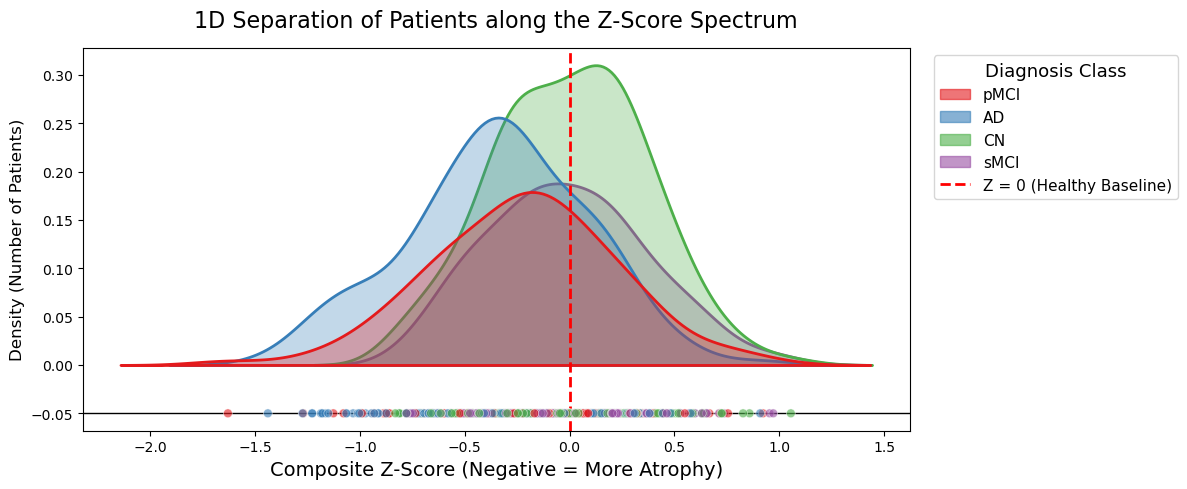

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Set up a wide, flat plot area
plt.figure(figsize=(12, 5))

# Change color schema (Options: 'Set1', 'tab10', 'husl', 'Set2', 'Dark2')
color_schema = 'Set1' 

# --- PLOT 1: The Density Lines ---
sns.kdeplot(
    data=z_df,
    x='Composite_Z',
    hue='Label',
    palette=color_schema,
    fill=True,
    alpha=0.3,
    linewidth=2,
    legend=False  # We will manually build a perfect legend below
)

# --- PLOT 2: The Raw 1D Number Line ---
z_df['Y_Line'] = -0.05 

sns.scatterplot(
    data=z_df,
    x='Composite_Z',
    y='Y_Line',
    hue='Label',
    palette=color_schema,
    alpha=0.6,
    s=40,
    legend=False, 
    zorder=5
)

# Draw the actual flat black "number line"
plt.axhline(-0.05, color='black', linewidth=1, zorder=0)

# Add a vertical red dashed line at 0.0 for reference
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# --- BUILD A CUSTOM, CLEAN LEGEND ---
# Get the unique diagnosis labels in the exact order Seaborn plotted them
labels = z_df['Label'].unique()
cmap = sns.color_palette(color_schema, n_colors=len(labels))

# Create colored boxes for each diagnosis class
legend_handles = [mpatches.Patch(color=cmap[i], alpha=0.6, label=label) for i, label in enumerate(labels)]

# Create a line icon for the red reference line
ref_line = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label='Z = 0 (Healthy Baseline)')
legend_handles.append(ref_line)

# Add the legend to the outside right of the plot
plt.legend(handles=legend_handles, title='Diagnosis Class', 
           bbox_to_anchor=(1.02, 1), loc='upper left', 
           fontsize=11, title_fontsize=13)

# Clean up the plot aesthetics
plt.title('1D Separation of Patients along the Z-Score Spectrum', fontsize=16, pad=15)
plt.xlabel('Composite Z-Score (Negative = More Atrophy)', fontsize=14)
plt.ylabel('Density (Number of Patients)', fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
# Save the final merged CSV with the Composite_Z column added
output_path = 'adni_mri_ucsf_merged_composite_z.csv'
z_df.to_csv(output_path, index=False)
print(f"Saved {len(z_df)} subjects to {output_path}")
print(f"Composite_Z column: min={z_df['Composite_Z'].min():.3f}, max={z_df['Composite_Z'].max():.3f}, mean={z_df['Composite_Z'].mean():.3f}")

Saved 577 subjects to adni_mri_ucsf_merged_composite_z.csv
Composite_Z column: min=-1.630, max=1.056, mean=-0.144


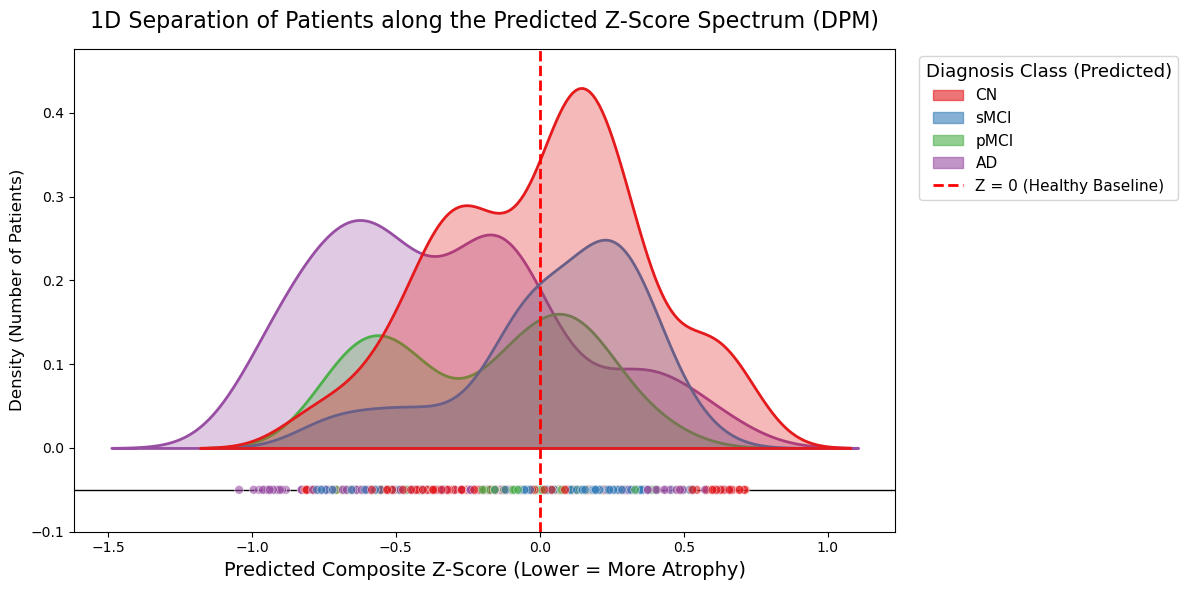

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# 1. Load predictions
csv_path = "/Users/khoale/Downloads/TABLE_DATA_ADNI/predictions_all_folds_combined.csv"
df = pd.read_csv(csv_path)

# Set up the figure size
plt.figure(figsize=(12, 6))

# Use the 'Set1' color schema
color_schema = 'Set1'

# Set the ordering of the clinical classes
order = ['CN', 'sMCI', 'pMCI', 'AD']
unique_labels = df['Label'].unique()
order = [l for l in order if l in unique_labels] + [l for l in unique_labels if l not in order]

# Map colors to classes explicitly to ensure consistency
cmap = sns.color_palette(color_schema, n_colors=len(order))
palette_dict = dict(zip(order, cmap))

# 2. Plot the Density Lines (KDE)
sns.kdeplot(
    data=df,
    x='Predicted_Z',
    hue='Label',
    hue_order=order,
    palette=palette_dict,
    fill=True,
    alpha=0.3,
    linewidth=2,
    legend=False
)

# 3. Plot the Raw 1D Number Line at the bottom
# We assign a constant Y value of -0.05 so all dots sit on the same horizontal line
df['Y_Line'] = -0.05

sns.scatterplot(
    data=df,
    x='Predicted_Z',
    y='Y_Line',
    hue='Label',
    hue_order=order,
    palette=palette_dict,
    alpha=0.6,
    s=40,
    legend=False,
    zorder=5
)

# Draw the actual flat black "number line"
plt.axhline(-0.05, color='black', linewidth=1, zorder=0)

# Add a vertical red dashed line at 0.0 for reference (our Healthy CN baseline)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# --- BUILD A CUSTOM, CLEAN LEGEND ---
# Create colored patches for each diagnosis class
legend_handles = [mpatches.Patch(color=palette_dict[l], alpha=0.6, label=l) for l in order]

# Create a line icon for the red reference line
ref_line = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label='Z = 0 (Healthy Baseline)')
legend_handles.append(ref_line)

# Add the legend to the outside right of the plot
plt.legend(
    handles=legend_handles, 
    title='Diagnosis Class (Predicted)', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    fontsize=11, 
    title_fontsize=13
)

# Set titles and labels
plt.title('1D Separation of Patients along the Predicted Z-Score Spectrum (DPM)', fontsize=16, pad=15)
plt.xlabel('Predicted Composite Z-Score (Lower = More Atrophy)', fontsize=14)
plt.ylabel('Density (Number of Patients)', fontsize=12)

# Adjust y limits to make sure the raw dot line at -0.05 is fully visible
current_ylim = plt.ylim()
plt.ylim(-0.1, current_ylim[1] * 1.05)

plt.tight_layout()
plt.show()

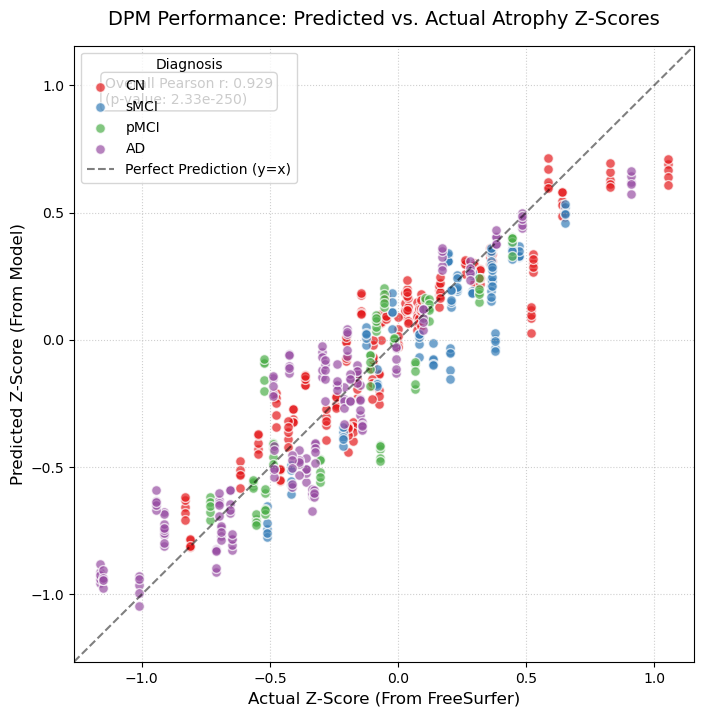

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Define colors matching Set1 palette
palette = {'CN': '#e41a1c', 'sMCI': '#377eb8', 'pMCI': '#4daf4a', 'AD': '#984ea3'}
diag_order = ['CN', 'sMCI', 'pMCI', 'AD']

plt.figure(figsize=(8, 8))

# Draw the scatter points class by class for a clean legend
for label in diag_order:
    sub_df = df[df['Label'] == label]
    plt.scatter(
        sub_df['Actual_Z'], 
        sub_df['Predicted_Z'], 
        label=label,
        color=palette[label],
        alpha=0.7, 
        edgecolors='w',
        s=50
    )

# Draw a perfect prediction diagonal line (y = x)
lims = [
    min(df['Actual_Z'].min(), df['Predicted_Z'].min()) - 0.1,
    max(df['Actual_Z'].max(), df['Predicted_Z'].max()) + 0.1
]
plt.plot(lims, lims, 'k--', alpha=0.5, label='Perfect Prediction (y=x)')

# Add text annotations for correlation
r_val, p_val = pearsonr(df['Actual_Z'], df['Predicted_Z'])
plt.text(
    0.05, 0.95, 
    f'Overall Pearson r: {r_val:.3f}\n(p-value: {p_val:.2e})',
    transform=plt.gca().transAxes, 
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('Actual Z-Score (From FreeSurfer)', fontsize=12)
plt.ylabel('Predicted Z-Score (From Model)', fontsize=12)
plt.title('DPM Performance: Predicted vs. Actual Atrophy Z-Scores', fontsize=14, pad=15)
plt.legend(title='Diagnosis')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

/var/folders/mx/wbd5pzln229_t5z_3wx42n8r0000gn/T/ipykernel_33858/520872376.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


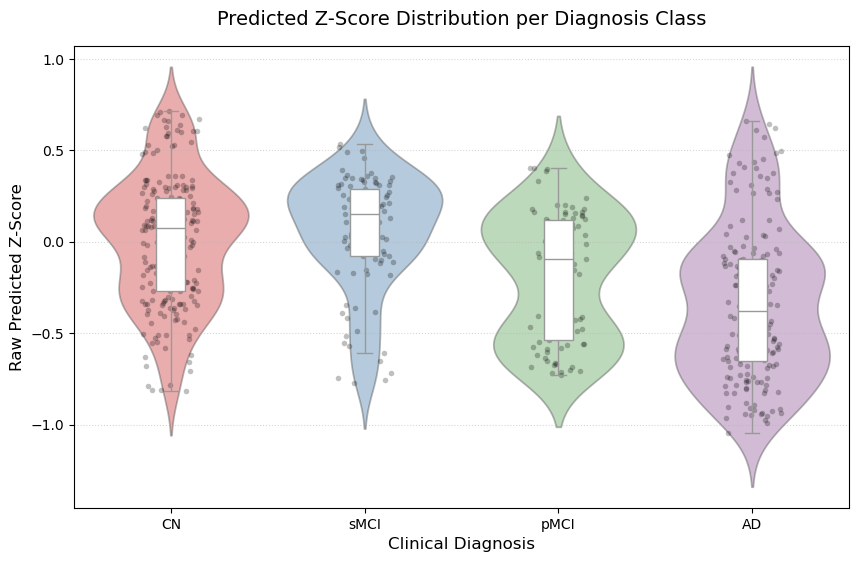

In [19]:
plt.figure(figsize=(10, 6))

# Plot the distribution density
sns.violinplot(
    data=df, 
    x='Label', 
    y='Predicted_Z', 
    order=diag_order,
    palette=palette,
    inner=None, 
    alpha=0.4
)

# Overlay a boxplot to see quartiles clearly
sns.boxplot(
    data=df, 
    x='Label', 
    y='Predicted_Z', 
    order=diag_order,
    width=0.15,
    color='white', 
    fliersize=0, # Turn off outlier dots so we don't duplicate them
    zorder=3
)

# Overlay individual patient points
sns.stripplot(
    data=df, 
    x='Label', 
    y='Predicted_Z', 
    order=diag_order,
    color='black', 
    alpha=0.25, 
    size=4,
    jitter=0.15,
    zorder=2
)

plt.title('Predicted Z-Score Distribution per Diagnosis Class', fontsize=14, pad=15)
plt.xlabel('Clinical Diagnosis', fontsize=12)
plt.ylabel('Raw Predicted Z-Score', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.show()

In [20]:
# Calculate absolute error for every prediction
df['Abs_Error'] = (df['Actual_Z'] - df['Predicted_Z']).abs()

summary = df.groupby('Label').agg(
    Mean_Actual_Z=('Actual_Z', 'mean'),
    Mean_Predicted_Z=('Predicted_Z', 'mean'),
    Average_Error=('Abs_Error', 'mean'),
    Standard_Deviation=('Predicted_Z', 'std')
).loc[diag_order]

print("--- DETAILED STATISTICAL SUMMARY OF PREDICTIONS ---")
display(summary.round(3))

--- DETAILED STATISTICAL SUMMARY OF PREDICTIONS ---


,Mean_Actual_Z,Mean_Predicted_Z,Average_Error,Standard_Deviation
Label,,,,
CN,0.008,0.010,0.114,0.354
sMCI,0.151,0.052,0.140,0.311
pMCI,-0.175,-0.192,0.133,0.345
AD,-0.350,-0.333,0.137,0.418
